In [1]:
# ============================================================
# NB1 · Cell 1 — Setup, GPU check, dataset path discovery
# ============================================================
import os, sys, json, random, time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- Reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# --- GPU check ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print()

# --- Dataset path auto-discovery (tries common Kaggle mount paths) ---
candidates = [
    "/kaggle/input/plantvillage-dataset/color",
    "/kaggle/input/plantvillage-dataset/plantvillage dataset/color",
    "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
]
COLOR_DIR = None
for c in candidates:
    if os.path.isdir(c) and any("Corn" in d for d in os.listdir(c)):
        COLOR_DIR = c
        break

if COLOR_DIR is None:
    print("⚠️  Couldn't find dataset at expected paths. Here's what's in /kaggle/input:")
    for d in sorted(os.listdir("/kaggle/input")):
        print(f"  {d}")
    raise FileNotFoundError("Inspect structure above and set COLOR_DIR manually.")

# --- Verify all 4 maize classes are present ---
maize_dirs = sorted([d for d in os.listdir(COLOR_DIR) if "Corn" in d])
assert len(maize_dirs) == 4, f"Expected 4 maize folders, got {len(maize_dirs)}"

print(f"Dataset path : {COLOR_DIR}")
print(f"Maize classes: {len(maize_dirs)}")
for d in maize_dirs:
    n = sum(1 for f in os.listdir(os.path.join(COLOR_DIR, d))
            if f.lower().endswith((".jpg", ".jpeg", ".png")))
    print(f"  {n:>5} images  {d}")

print("\nCell 1 complete ✅") 

Device : cuda
GPU    : Tesla T4

Dataset path : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Maize classes: 4
    513 images  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192 images  Corn_(maize)___Common_rust_
    985 images  Corn_(maize)___Northern_Leaf_Blight
   1162 images  Corn_(maize)___healthy

Cell 1 complete ✅


In [1]:
# ============================================================
# NB1 · Cell 2 — Splits, loaders, model, optimizer
# ============================================================

# --- Friendly class names ---
def friendly(name):
    n = name.lower()
    if "cercospora" in n or "gray" in n: return "Gray Leaf Spot"
    if "common_rust" in n or "rust" in n: return "Common Rust"
    if "northern" in n or "blight" in n:  return "Northern Leaf Blight"
    if "healthy" in n:                     return "Healthy"
    return name

raw_names      = sorted(maize_dirs)
DISPLAY_NAMES  = [friendly(n) for n in raw_names]
CLASS_TO_IDX   = {raw_names[i]: i for i in range(4)}

# --- Build (path, label) pairs ---
all_paths, all_labels = [], []
for folder_name in raw_names:
    label = CLASS_TO_IDX[folder_name]
    folder_path = os.path.join(COLOR_DIR, folder_name)
    for img in os.listdir(folder_path):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(folder_path, img))
            all_labels.append(label)
print(f"Total images: {len(all_paths)}")

# --- Stratified 70/15/15 split ---
train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)
print(f"Train/Val/Test: {len(train_paths)} / {len(val_paths)} / {len(test_paths)}")

# --- Transforms ---
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# --- Dataset class ---
class MaizeDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), self.labels[i]

train_ds = MaizeDataset(train_paths, train_labels, train_tfm)
val_ds   = MaizeDataset(val_paths,   val_labels,   eval_tfm)
test_ds  = MaizeDataset(test_paths,  test_labels,  eval_tfm)

# --- Weighted sampler (handles class imbalance) ---
counts = Counter(train_labels)
class_weights  = [1.0 / counts[i] for i in range(4)]
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)

# --- DataLoaders (num_workers=0 to avoid Kaggle multiprocessing spam) ---
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# --- Quick batch sanity check ---
xb, yb = next(iter(train_loader))
print(f"Batch shape : {tuple(xb.shape)}   pixel range [{xb.min():.2f}, {xb.max():.2f}]")

# --- Build ResNet50 + custom head ---
print("\nLoading ResNet50 (ImageNet V2 weights)...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 4)
)
model = model.to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

# --- Loss, optimizer, scheduler ---
EPOCHS       = 15
LR           = 1e-4
WEIGHT_DECAY = 0.05
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("\nCell 2 complete ✅")

NameError: name 'maize_dirs' is not defined

In [2]:
# ============================================================
# NB1 · Cell 1 — Setup, GPU check, dataset path discovery
# ============================================================
import os, sys, json, random, time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# --- Reproducibility ---
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# --- GPU check ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print()

# --- Dataset path auto-discovery (tries common Kaggle mount paths) ---
candidates = [
    "/kaggle/input/plantvillage-dataset/color",
    "/kaggle/input/plantvillage-dataset/plantvillage dataset/color",
    "/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color",
]
COLOR_DIR = None
for c in candidates:
    if os.path.isdir(c) and any("Corn" in d for d in os.listdir(c)):
        COLOR_DIR = c
        break

if COLOR_DIR is None:
    print("⚠️  Couldn't find dataset at expected paths. Here's what's in /kaggle/input:")
    for d in sorted(os.listdir("/kaggle/input")):
        print(f"  {d}")
    raise FileNotFoundError("Inspect structure above and set COLOR_DIR manually.")

# --- Verify all 4 maize classes are present ---
maize_dirs = sorted([d for d in os.listdir(COLOR_DIR) if "Corn" in d])
assert len(maize_dirs) == 4, f"Expected 4 maize folders, got {len(maize_dirs)}"

print(f"Dataset path : {COLOR_DIR}")
print(f"Maize classes: {len(maize_dirs)}")
for d in maize_dirs:
    n = sum(1 for f in os.listdir(os.path.join(COLOR_DIR, d))
            if f.lower().endswith((".jpg", ".jpeg", ".png")))
    print(f"  {n:>5} images  {d}")

print("\nCell 1 complete ✅")

Device : cuda
GPU    : Tesla T4

Dataset path : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
Maize classes: 4
    513 images  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192 images  Corn_(maize)___Common_rust_
    985 images  Corn_(maize)___Northern_Leaf_Blight
   1162 images  Corn_(maize)___healthy

Cell 1 complete ✅


In [3]:
# ============================================================
# NB1 · Cell 2 — Splits, loaders, model, optimizer
# ============================================================

# --- Friendly class names ---
def friendly(name):
    n = name.lower()
    if "cercospora" in n or "gray" in n: return "Gray Leaf Spot"
    if "common_rust" in n or "rust" in n: return "Common Rust"
    if "northern" in n or "blight" in n:  return "Northern Leaf Blight"
    if "healthy" in n:                     return "Healthy"
    return name

raw_names      = sorted(maize_dirs)
DISPLAY_NAMES  = [friendly(n) for n in raw_names]
CLASS_TO_IDX   = {raw_names[i]: i for i in range(4)}

# --- Build (path, label) pairs ---
all_paths, all_labels = [], []
for folder_name in raw_names:
    label = CLASS_TO_IDX[folder_name]
    folder_path = os.path.join(COLOR_DIR, folder_name)
    for img in os.listdir(folder_path):
        if img.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(folder_path, img))
            all_labels.append(label)
print(f"Total images: {len(all_paths)}")

# --- Stratified 70/15/15 split ---
train_paths, tmp_paths, train_labels, tmp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, stratify=all_labels, random_state=SEED)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    tmp_paths, tmp_labels, test_size=0.50, stratify=tmp_labels, random_state=SEED)
print(f"Train/Val/Test: {len(train_paths)} / {len(val_paths)} / {len(test_paths)}")

# --- Transforms ---
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# --- Dataset class ---
class MaizeDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), self.labels[i]

train_ds = MaizeDataset(train_paths, train_labels, train_tfm)
val_ds   = MaizeDataset(val_paths,   val_labels,   eval_tfm)
test_ds  = MaizeDataset(test_paths,  test_labels,  eval_tfm)

# --- Weighted sampler (handles class imbalance) ---
counts = Counter(train_labels)
class_weights  = [1.0 / counts[i] for i in range(4)]
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)

# --- DataLoaders (num_workers=0 to avoid Kaggle multiprocessing spam) ---
BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# --- Quick batch sanity check ---
xb, yb = next(iter(train_loader))
print(f"Batch shape : {tuple(xb.shape)}   pixel range [{xb.min():.2f}, {xb.max():.2f}]")

# --- Build ResNet50 + custom head ---
print("\nLoading ResNet50 (ImageNet V2 weights)...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(model.fc.in_features, 4)
)
model = model.to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

# --- Loss, optimizer, scheduler ---
EPOCHS       = 15
LR           = 1e-4
WEIGHT_DECAY = 0.05
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("\nCell 2 complete ✅")

Total images: 3852
Train/Val/Test: 2696 / 578 / 578
Batch shape : (32, 3, 224, 224)   pixel range [-2.12, 2.64]

Loading ResNet50 (ImageNet V2 weights)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 214MB/s] 


Trainable parameters: 23,516,228

Cell 2 complete ✅


In [4]:
# ============================================================
# NB1 · Cell 3 — Training loop
# ============================================================
import time

CKPT_PATH = "/kaggle/working/resnet50_best.pt"

# --- Helper functions ---
def train_one_epoch(model, loader, optimizer, criterion, mid_print_at=None):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    n_batches = len(loader)
    for i, (x, y) in enumerate(loader, start=1):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * x.size(0)
        total_correct += (out.argmax(1) == y).sum().item()
        total         += x.size(0)
        # Mid-epoch heartbeat so you know it's alive
        if mid_print_at and i == mid_print_at:
            print(f"   ... batch {i}/{n_batches}, running loss={total_loss/total:.4f}", flush=True)
    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds, labs = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.numpy())
    preds = np.array(preds); labs = np.array(labs)
    return float((preds == labs).mean()), float(f1_score(labs, preds, average="macro"))

# --- Main loop ---
history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
best_val_f1 = 0.0
mid_print = len(train_loader) // 2   # heartbeat at halfway through each epoch

print(f"Training ResNet50 for {EPOCHS} epochs on {device}")
print(f"Train batches/epoch: {len(train_loader)}   Val batches: {len(val_loader)}")
print("=" * 78, flush=True)

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()
    print(f"Epoch {epoch:02d}/{EPOCHS} - training...", flush=True)

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, mid_print_at=mid_print)
    val_acc, val_f1 = evaluate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    elapsed = time.time() - ep_start
    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        flag = "  ↳ saved (new best)"

    print(f"Epoch {epoch:02d}/{EPOCHS} [{elapsed:.0f}s]  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}{flag}", flush=True)

total_time = time.time() - t_start
print("=" * 78)
print(f"Total training time: {total_time/60:.1f} min")
print(f"Best val macro-F1  : {best_val_f1:.4f}")
print(f"Checkpoint saved to: {CKPT_PATH}")
print("\nCell 3 complete ✅")

Training ResNet50 for 15 epochs on cuda
Train batches/epoch: 85   Val batches: 19
Epoch 01/15 - training...
   ... batch 42/85, running loss=0.8265
Epoch 01/15 [53s]  train_loss=0.5149  train_acc=0.8561  val_acc=0.9689  val_f1=0.9575  ↳ saved (new best)
Epoch 02/15 - training...
   ... batch 42/85, running loss=0.1439
Epoch 02/15 [48s]  train_loss=0.1238  train_acc=0.9622  val_acc=0.9810  val_f1=0.9738  ↳ saved (new best)
Epoch 03/15 - training...
   ... batch 42/85, running loss=0.0870
Epoch 03/15 [49s]  train_loss=0.0743  train_acc=0.9777  val_acc=0.9810  val_f1=0.9732
Epoch 04/15 - training...
   ... batch 42/85, running loss=0.0521
Epoch 04/15 [45s]  train_loss=0.0487  train_acc=0.9852  val_acc=0.9775  val_f1=0.9687
Epoch 05/15 - training...
   ... batch 42/85, running loss=0.0404
Epoch 05/15 [45s]  train_loss=0.0474  train_acc=0.9863  val_acc=0.9758  val_f1=0.9661
Epoch 06/15 - training...
   ... batch 42/85, running loss=0.0278
Epoch 06/15 [45s]  train_loss=0.0345  train_acc=0.98

Loaded best checkpoint from /kaggle/working/resnet50_best.pt

Test Accuracy   : 0.9792
Test Macro F1   : 0.9698

Per-class metrics:
                      precision    recall  f1-score   support

      Gray Leaf Spot     0.9577    0.8831    0.9189        77
         Common Rust     1.0000    1.0000    1.0000       179
Northern Leaf Blight     0.9416    0.9797    0.9603       148
             Healthy     1.0000    1.0000    1.0000       174

            accuracy                         0.9792       578
           macro avg     0.9748    0.9657    0.9698       578
        weighted avg     0.9794    0.9792    0.9790       578

Confusion matrix (rows = true, cols = predicted):
                       Gray L  Common  Northe  Health
  Gray Leaf Spot            68       0       9       0
  Common Rust                0     179       0       0
  Northern Leaf Blight       3       0     145       0
  Healthy                    0       0       0     174


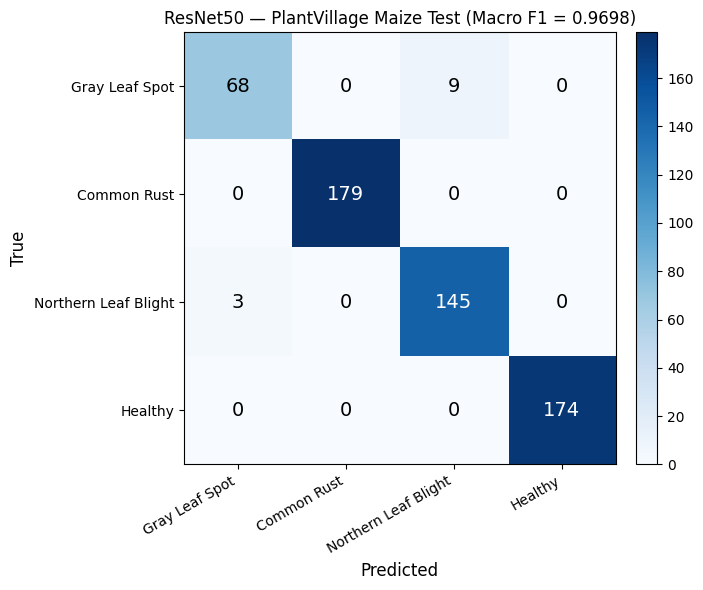


Confusion matrix saved to: /kaggle/working/resnet50_confusion_matrix.png

Cell 4 complete ✅


In [5]:
# ============================================================
# NB1 · Cell 4 — Test eval, classification report, confusion matrix
# ============================================================

# Load the best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()
print(f"Loaded best checkpoint from {CKPT_PATH}\n")

# Run inference on test set
all_preds, all_labs = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        out = model(x)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labs.extend(y.numpy())
all_preds = np.array(all_preds)
all_labs  = np.array(all_labs)

# ---- Headline metrics ----
test_acc = float((all_preds == all_labs).mean())
test_f1  = float(f1_score(all_labs, all_preds, average="macro"))
print("=" * 50)
print(f"Test Accuracy   : {test_acc:.4f}")
print(f"Test Macro F1   : {test_f1:.4f}")
print("=" * 50)

# ---- Per-class report ----
print("\nPer-class metrics:")
print(classification_report(all_labs, all_preds, target_names=DISPLAY_NAMES, digits=4))

# ---- Confusion matrix ----
cm = confusion_matrix(all_labs, all_preds)
print("Confusion matrix (rows = true, cols = predicted):")
header = "                       " + "  ".join(f"{n[:6]:>6}" for n in DISPLAY_NAMES)
print(header)
for i, name in enumerate(DISPLAY_NAMES):
    row = "  ".join(f"{cm[i, j]:>6}" for j in range(4))
    print(f"  {name:<20}  {row}")

# ---- Plot confusion matrix ----
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(DISPLAY_NAMES, rotation=30, ha="right")
ax.set_yticklabels(DISPLAY_NAMES)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title(f"ResNet50 — PlantVillage Maize Test (Macro F1 = {test_f1:.4f})", fontsize=12)
for i in range(4):
    for j in range(4):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=14)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()

CM_PATH = "/kaggle/working/resnet50_confusion_matrix.png"
plt.savefig(CM_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nConfusion matrix saved to: {CM_PATH}")
print("\nCell 4 complete ✅")

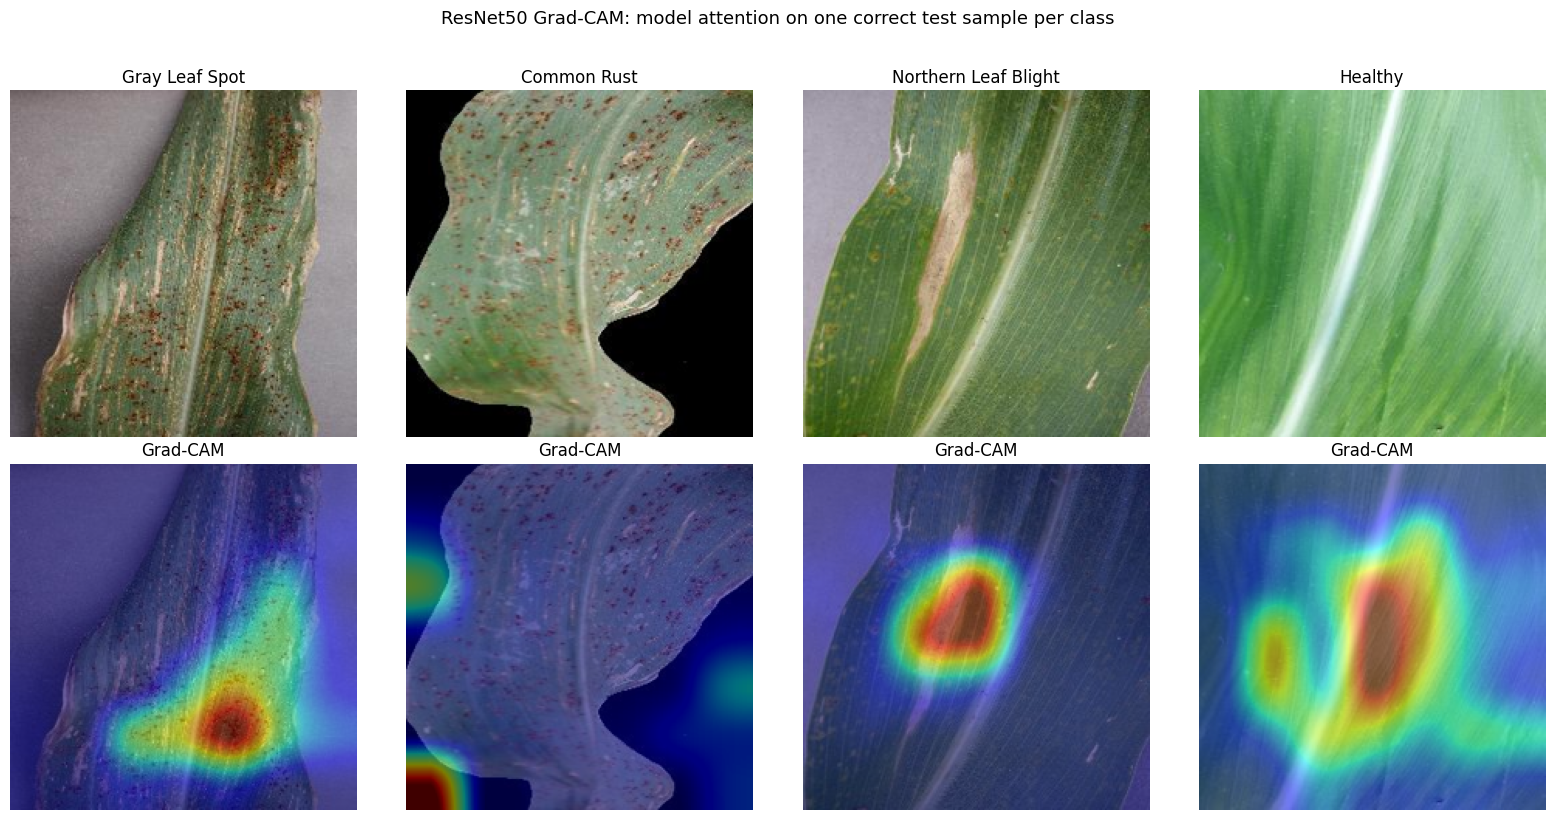

Grad-CAM saved to: /kaggle/working/resnet50_gradcam.png

Results saved to: /kaggle/working/nb1_resnet50_results.json

PAPER TABLE 1 — ROW 1 (ResNet50 baseline)
  Test Macro F1     : 0.9698
  Test Accuracy     : 0.9792
  Best Val Macro F1 : 0.9809

Per-class F1:
  Gray Leaf Spot          0.9189
  Common Rust             1.0000
  Northern Leaf Blight    0.9603
  Healthy                 1.0000

Cell 5 complete ✅

NB1 is officially DONE. 🎉


In [6]:
# ============================================================
# NB1 · Cell 5 — Grad-CAM + save results JSON
# ============================================================

# ---------- Grad-CAM implementation ----------
class GradCAM:
    """Grad-CAM with forward+backward hooks on a chosen conv layer."""
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients   = None
        self.fwd = target_layer.register_forward_hook(self._save_act)
        self.bwd = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out):  self.activations = out.detach()
    def _save_grad(self, m, gi, go):   self.gradients   = go[0].detach()

    def __call__(self, x_tensor, target_class):
        self.model.eval()
        x = x_tensor.clone().requires_grad_(True)
        out = self.model(x)
        self.model.zero_grad()
        out[0, target_class].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze()
        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.cpu().numpy()

    def close(self):
        self.fwd.remove(); self.bwd.remove()

# Hook into ResNet50's last residual block
gradcam = GradCAM(model, model.layer4[-1])

# Find one correctly-classified test image per class
test_paths_arr = np.array(test_paths)
test_labs_arr  = np.array(test_labels)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for c in range(4):
    correct_mask = (test_labs_arr == c) & (all_preds == c)
    idxs = np.where(correct_mask)[0]
    if len(idxs) == 0:
        for r in range(2):
            axes[r, c].axis("off")
        axes[0, c].set_title(f"{DISPLAY_NAMES[c]} (no correct)")
        continue
    i = int(idxs[0])
    img = Image.open(test_paths_arr[i]).convert("RGB")
    x_in = eval_tfm(img).unsqueeze(0).to(device)
    cam = gradcam(x_in, target_class=c)

    img_disp = np.array(img.resize((224, 224))) / 255.0
    cam_resized = np.array(
        Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224))
    ) / 255.0

    axes[0, c].imshow(img_disp)
    axes[0, c].set_title(DISPLAY_NAMES[c], fontsize=12)
    axes[0, c].axis("off")

    axes[1, c].imshow(img_disp)
    axes[1, c].imshow(cam_resized, cmap="jet", alpha=0.5)
    axes[1, c].set_title("Grad-CAM", fontsize=12)
    axes[1, c].axis("off")

plt.suptitle("ResNet50 Grad-CAM: model attention on one correct test sample per class", fontsize=13, y=1.02)
plt.tight_layout()
GC_PATH = "/kaggle/working/resnet50_gradcam.png"
plt.savefig(GC_PATH, dpi=150, bbox_inches="tight")
plt.show()
gradcam.close()
print(f"Grad-CAM saved to: {GC_PATH}\n")

# ---------- Save full results to JSON ----------
per_class_f1 = f1_score(all_labs, all_preds, average=None)

results = {
    "notebook":      "NB1_ResNet50_baseline",
    "model":         "ResNet50",
    "pretrained":    "ImageNet V2",
    "dataset":       "PlantVillage_Maize",
    "classes":       DISPLAY_NAMES,
    "n_train":       len(train_paths),
    "n_val":         len(val_paths),
    "n_test":        len(test_paths),
    "config": {
        "img_size":     IMG_SIZE,
        "batch_size":   BATCH_SIZE,
        "epochs":       EPOCHS,
        "lr":           LR,
        "weight_decay": WEIGHT_DECAY,
        "seed":         SEED,
        "optimizer":    "AdamW",
        "scheduler":    "CosineAnnealingLR",
    },
    "test_accuracy":   float(test_acc),
    "test_macro_f1":   float(test_f1),
    "per_class_f1":    {DISPLAY_NAMES[i]: float(per_class_f1[i]) for i in range(4)},
    "confusion_matrix": cm.tolist(),
    "history":         history,
    "best_val_f1":     float(best_val_f1),
}

OUT_PATH = "/kaggle/working/nb1_resnet50_results.json"
with open(OUT_PATH, "w") as f:
    json.dump(results, f, indent=2)
print(f"Results saved to: {OUT_PATH}\n")

# Print a paper-ready summary
print("=" * 60)
print("PAPER TABLE 1 — ROW 1 (ResNet50 baseline)")
print("=" * 60)
print(f"  Test Macro F1     : {test_f1:.4f}")
print(f"  Test Accuracy     : {test_acc:.4f}")
print(f"  Best Val Macro F1 : {best_val_f1:.4f}")
print("\nPer-class F1:")
for name in DISPLAY_NAMES:
    print(f"  {name:<22}  {results['per_class_f1'][name]:.4f}")
print("\nCell 5 complete ✅")
print("\nNB1 is officially DONE. 🎉")